In [89]:
import requests
import pandas as pd
import sqlite3
import datetime
from os import path

In [90]:
def api_request(url, timeout_seconds=60):
    """Fetches API data with a defined timeout handling."""
    try:
        r = requests.get(url, timeout=timeout_seconds)
        if r.status_code == 200:
            return r.json()
        print(f"Error with API request, code: {r.status_code}")
    except requests.exceptions.Timeout:
        print(f"API request timed out after {timeout_seconds} seconds.")
    except requests.exceptions.RequestException as e:
        print(f"API request failed: {e}")
    return None

In [91]:
def get_station_info(station_data, field_name='Street'):
    """Retrieves a specific metadata field for a station using its name."""
    try:
        stations_index = pd.read_csv("resources/indices_staions.csv").set_index('name')['index'].to_dict()
        idx = stations_index.get(field_name)
        return [item[idx] for item in station_data.values()] if idx is not None else []
    except FileNotFoundError:
        print("resources/indices_staions.csv not found.")
        return []

In [92]:
def filter_stations(stations, by_param="City", filter_val="Hamburg"):
    """Filters the station dictionary by a specified parameter."""
    try:
        stations_index = pd.read_csv("Test_DBs/indices_staions.csv").set_index('name')['index'].to_dict()
        idx = stations_index[by_param]
        return {k: v for k, v in stations.items() if v[idx] == filter_val}
    except KeyError as e:
        print(f"by_param: {by_param} is not a valid key. Error: {e}")
        return {}
    except FileNotFoundError:
        print("resources/indices_staions.csv not found.")
        return {}

In [93]:
def download_and_store_data(conn, stations, component, date_from, date_to):
    """Downloads environmental measurements and stores them in SQLite."""
    cursor = conn.cursor()
    base_url = "https://www.umweltbundesamt.de/api/air_data/v4/measures/json"
    
    for station_id in stations.keys():
        print(f"Fetching component {component} for station {station_id}...")
        url = (f"{base_url}?station={station_id}&component={component}"
               f"&date_from={date_from}&date_to={date_to}&time_from=1&time_to=24&lang=de")
               
        data = api_request(url)
        if not data or "data" not in data or str(station_id) not in data["data"]:
            continue
            
        records = []
        for timestamp, values in data["data"][str(station_id)].items():
            val = values[0] if isinstance(values, list) and values else values
            if val is not None:
                records.append((station_id, str(component), timestamp, val))
        
        cursor.executemany('''
            INSERT OR IGNORE INTO measurements (station_id, component_id, timestamp, value)
            VALUES (?, ?, ?, ?)
        ''', records)
        conn.commit()
        print(f"Stored {len(records)} entries for station {station_id}.")


In [94]:
def download_and_store_data(conn, stations, component, date_from, date_to):
    """
    Downloads environmental measurements and stores them in SQLite.

    Uses the array layout described by indices:
    [component id, scope id, value, date end, index]
    """
    cursor = conn.cursor()
    base_url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json"

    for station_id in stations.keys():
        print(f"Fetching component {component} for station {station_id}...")
        url = (
            f"{base_url}"
            f"?station={station_id}"
            f"&component={component}"
            f"&date_from={date_from}"
            f"&date_to={date_to}"
            f"&time_from=1&time_to=24&lang=de"
        )

        data = api_request(url)
        if not data or "data" not in data:
            print("No data field in response, skipping.")
            continue

        station_key = str(station_id)
        station_data = data["data"].get(station_key, {})
        if not station_data:
            print(f"No measurements for station {station_key}")
            continue

        records = []
        for date_start, arr in station_data.items():
            # arr: [component id, scope id, value, date end, index]
            if not isinstance(arr, (list, tuple)) or len(arr) < 3:
                print(f"Malformed entry at {date_start} for station {station_key}: {arr}")
                continue

            component_id = arr[0]   # component id
            value = arr[2]          # measurement value

            if value is None:
                continue

            records.append(
                (
                    station_key,
                    str(component_id),
                    date_start,      # timestamp = date start
                    float(value),
                )
            )

        if records:
            cursor.executemany(
                """
                INSERT OR IGNORE INTO measurements
                    (station_id, component_id, timestamp, value)
                VALUES (?, ?, ?, ?)
                """,
                records,
            )
            conn.commit()
            print(f"Stored {len(records)} entries for station {station_id}.")
        else:
            print(f"No valid records for station {station_id}.")


In [95]:
def init_db(db_name="capstone_air_data.db"):
    """Initializes the SQLite database to store measurement data."""
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS measurements (
            station_id TEXT,
            component_id TEXT,
            timestamp TEXT,
            value REAL,
            UNIQUE(station_id, component_id, timestamp)
        )
    ''')
    conn.commit()
    return conn

In [108]:
def load_measurements(
    db_name="capstone_air_data.db",
    station_ids=None,          # list like ["123", "456"] or None for all
    component_ids=None,        # list like ["1", "8"] or None for all
    start_ts=None,             # e.g. "2025-06-01 00:00:00" or "2025-06-01"
    end_ts=None                # e.g. "2025-06-30 23:59:59" or "2025-06-30"
):
    """
    Load data from the 'measurements' table as a pandas DataFrame.
    All filters are optional.
    """
    conn = sqlite3.connect(db_name)
    try:
        base_query = """
            SELECT station_id, component_id, timestamp, value
            FROM measurements
        """
        conditions = []
        params = []

        if station_ids:
            placeholders = ",".join(["?"] * len(station_ids))
            conditions.append(f"station_id IN ({placeholders})")
            params.extend(station_ids)

        if component_ids:
            placeholders = ",".join(["?"] * len(component_ids))
            conditions.append(f"component_id IN ({placeholders})")
            params.extend(component_ids)

        if start_ts:
            conditions.append("timestamp >= ?")
            params.append(start_ts)

        if end_ts:
            conditions.append("timestamp <= ?")
            params.append(end_ts)

        if conditions:
            query = base_query + " WHERE " + " AND ".join(conditions)
        else:
            query = base_query

        df = pd.read_sql_query(query, conn, params=params)
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df = df.set_index("timestamp")
        return df
    finally:
        conn.close()


In [ ]:
# 1. Fetch metadata
meta_url = "https://luftdaten.umweltbundesamt.de/api-proxy/meta/json?use=airquality&date_from=2025-06-01&date_to=2026-06-30&time_from=1&time_to=24&lang=de"
meta_data = api_request(meta_url, timeout_seconds=10)

database_folder = "Test_DBs"
component_select = 1
''' Other components are:
    {'1': ['1', 'PM10', 'PM₁₀', 'µg/m³', 'Feinstaub'],
    '2': ['2', 'CO', 'CO', 'mg/m³', 'Kohlenmonoxid'],
    '3': ['3', 'O3', 'O₃', 'µg/m³', 'Ozon'],
    '4': ['4', 'SO2', 'SO₂', 'µg/m³', 'Schwefeldioxid'],
    '5': ['5', 'NO2', 'NO₂', 'µg/m³', 'Stickstoffdioxid'],
    '6': ['6', 'PM10PB', 'Pb', 'µg/m³', 'Blei im Feinstaub'],
    '7': ['7', 'PM10BAP', 'BaP', 'ng/m³', 'Benzo(a)pyren im Feinstaub'],
    '8': ['8', 'CHB', 'C₆H₆', 'µg/m³', 'Benzol'],
    '9': ['9', 'PM2', 'PM₂,₅', 'µg/m³', 'Feinstaub'],
    '10': ['10', 'PM10AS', 'As', 'ng/m³', 'Arsen im Feinstaub'],
    '11': ['11', 'PM10CD', 'Cd', 'ng/m³', 'Cadmium im Feinstaub'],
    '12': ['12', 'PM10NI', 'Ni', 'ng/m³', 'Nickel im Feinstaub']}
    '''


if meta_data and "stations" in meta_data:
    # 2. Filter stations (e.g., Hamburg)
    hamburg_stations = filter_stations(meta_data["stations"], by_param="City", filter_val="Hamburg")
    
    # 3. Initialize Database
    str_db_filename ="UWB"+ datetime.date.today().__str__() + "_"+str(component_select) +".db"
    filepath = path.join(database_folder, str_db_filename)
    db_connection = init_db(db_name=filepath)
    
    # 4. Download and store PM10 (component=1) for June 2025
    
    download_and_store_data(
        conn=db_connection, 
        stations=hamburg_stations, 
        component=component_select,
        date_from="2024-01-01", 
        date_to="2024-02-01"
    )
    
    db_connection.close()
    print("Data ingestion complete.")

Fetching component ['1', '2'] for station 784...
No measurements for station 784
Fetching component ['1', '2'] for station 791...
No measurements for station 791
Fetching component ['1', '2'] for station 802...
No measurements for station 802
Fetching component ['1', '2'] for station 835...
No measurements for station 835
Fetching component ['1', '2'] for station 840...
No measurements for station 840
Fetching component ['1', '2'] for station 844...
No measurements for station 844
Fetching component ['1', '2'] for station 846...
No measurements for station 846
Fetching component ['1', '2'] for station 855...
No measurements for station 855
Fetching component ['1', '2'] for station 857...
No measurements for station 857
Fetching component ['1', '2'] for station 10348...
No measurements for station 10348
Fetching component ['1', '2'] for station 826...
No measurements for station 826
Fetching component ['1', '2'] for station 10466...
No measurements for station 10466
Data ingestion compl

In [130]:
# all data
df_all = load_measurements(db_name=filepath)

In [119]:
df_all.head()

,station_id,component_id,value
timestamp,,,
2024-01-01 11:00:00,784,1,23.0
2024-01-02 11:00:00,784,1,11.0
2024-01-03 11:00:00,784,1,3.0
2024-01-04 11:00:00,784,1,4.0
2024-01-05 11:00:00,784,1,8.0


In [120]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 87524 entries, 2024-01-01 11:00:00 to 2025-01-01 23:00:00
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station_id    87524 non-null  object 
 1   component_id  87524 non-null  object 
 2   value         87524 non-null  float64
dtypes: float64(1), object(2)
memory usage: 2.7+ MB


In [189]:
pip install requests python-dateutil

Note: you may need to restart the kernel to use updated packages.


In [121]:
df_all

,station_id,component_id,value
timestamp,,,
2024-01-01 11:00:00,784,1,23.0
2024-01-02 11:00:00,784,1,11.0
2024-01-03 11:00:00,784,1,3.0
2024-01-04 11:00:00,784,1,4.0
2024-01-05 11:00:00,784,1,8.0
...,...,...,...
2025-01-01 19:00:00,10348,1,17.0
2025-01-01 20:00:00,10348,1,16.0
2025-01-01 21:00:00,10348,1,15.0


<Axes: xlabel='timestamp'>

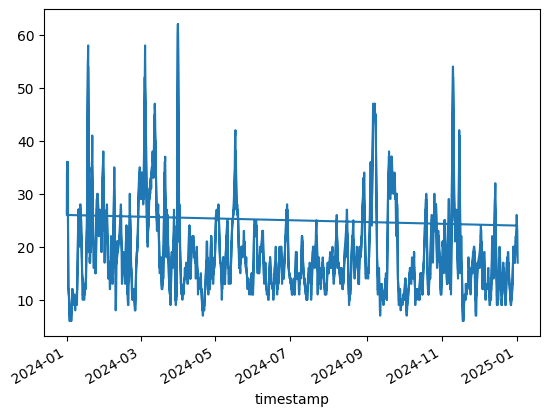

In [123]:
df_all[(df_all['station_id']=="844") ]['value'].plot(kind='line')

In [124]:
import seaborn as sns

<Axes: xlabel='timestamp', ylabel='value'>

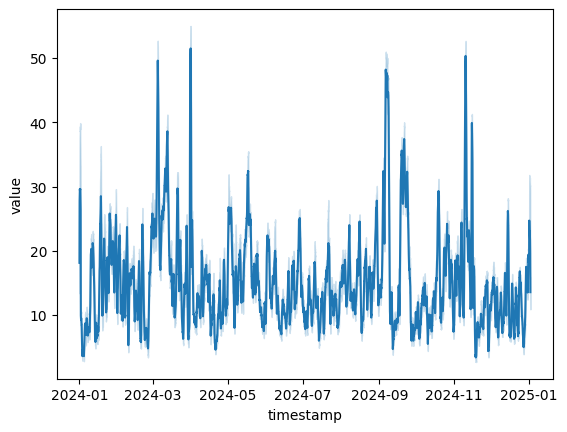

In [ ]:
sns.lineplot(df_all, x=df_all.index, y="value")

In [103]:
import json

def debug_print_one_measure(
    station_id,
    component,
    date_from,
    date_to,
    time_from=1,
    time_to=24,
    lang="de",
):
    base_url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json"
    url = (
        f"{base_url}"
        f"?station={station_id}"
        f"&component={component}"
        f"&date_from={date_from}"
        f"&date_to={date_to}"
        f"&time_from={time_from}&time_to={time_to}&lang={lang}"
    )
    data = api_request(url)
    if not data:
        print("No data returned")
        return

    # Pretty-print the indices section
    print("=== indices ===")
    print(json.dumps(data.get("indices", {}), indent=2, ensure_ascii=False))

    # Pick one timestamp entry (first one) for this station
    station_key = str(station_id)
    station_data = data.get("data", {}).get(station_key, {})
    if not station_data:
        print(f"No data entries for station {station_key}")
        return

    first_ts, arr = next(iter(station_data.items()))
    print("\n=== one data row ===")
    print(f"timestamp: {first_ts}")
    print(f"raw array: {arr}")

    # If indices["data"] exists, show a mapping
    data_indices = data.get("indices", {}).get("data", {})
    print("\n=== mapping array positions (indices['data']) ===")
    for field_name, idx in data_indices.items():
        try:
            print(f"{field_name} (idx {idx}): {arr[idx]}")
        except Exception as e:
            print(f"{field_name} (idx {idx}): ERROR -> {e}")


In [104]:
# Choose a station+component where you know data exists
debug_print_one_measure(
    station_id="1608",     # replace with one of your stations
    component=1,           # e.g. PM10
    date_from="2025-06-01",
    date_to="2025-06-02"
)


=== indices ===
{
  "data": {
    "station id": {
      "date start": [
        "component id",
        "scope id",
        "value",
        "date end",
        "index"
      ]
    }
  }
}

=== one data row ===
timestamp: 2025-06-01 00:00:00
raw array: [1, 6, 9, '2025-06-01 01:00:00', '1']

=== mapping array positions (indices['data']) ===
station id (idx {'date start': ['component id', 'scope id', 'value', 'date end', 'index']}): ERROR -> list indices must be integers or slices, not dict


In [134]:
def download_and_store_data(conn, stations, components, date_from, date_to):
    """
    Downloads multiple components and stores in SQLite.

    Uses the array layout:
        [component id, scope id, value, date end, index]
    """
    cursor = conn.cursor()
    base_url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json"

    for station_id in stations.keys():
        station_key = str(station_id)
        for component in components:
            print(f"Fetching component {component} for station {station_id}...")

            url = (
                f"{base_url}"
                f"?station={station_id}"
                f"&component={component}"
                f"&date_from={date_from}"
                f"&date_to={date_to}"
                f"&time_from=1&time_to=24&lang=de"
            )

            data = api_request(url, timeout_seconds=10)
            if not data or "data" not in data:
                print(f"No data field for component {component}, station {station_id}, skipping.")
                continue

            station_data = data["data"].get(station_key, {})
            if not station_data:
                print(f"No measurements for station {station_key} (component {component})")
                continue

            records = []
            for date_start, arr in station_data.items():
                if not isinstance(arr, (list, tuple)) or len(arr) < 3:
                    print(f"Malformed entry at {date_start} for station {station_key}: {arr}")
                    continue

                component_id = arr[0]
                value = arr[2]

                if value is None:
                    continue

                records.append(
                    (
                        station_key,
                        str(component_id),
                        date_start,
                        float(value),
                    )
                )

            if records:
                cursor.executemany(
                    """
                    INSERT OR IGNORE INTO measurements
                        (station_id, component_id, timestamp, value)
                    VALUES (?, ?, ?, ?)
                    """,
                    records,
                )
                conn.commit()
                print(f"Stored {len(records)} entries for station {station_key} (component {component}).")
            else:
                print(f"No valid records for station {station_key} (component {component}).")


In [147]:
### multiple components
def download_and_store_data(
    conn,
    stations,
    components,      # list of ints, e.g. [1, 2, 3]
    date_from,
    date_to,
):
    cursor = conn.cursor()
    base_url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json"

    # build one component string (e.g. "1,2,3")
    comp_str = ",".join(map(str, components))

    for station_id in stations.keys():
        station_key = str(station_id)
        print(f"Fetching components {comp_str} for station {station_id}...")

        url = (
            f"{base_url}"
            f"?station={station_id}"
            f"&component={comp_str}"
            f"&date_from={date_from}"
            f"&date_to={date_to}"
            f"&time_from=1&time_to=24&lang=de"
        )
        print(url)

        data = api_request(url, timeout_seconds=10)
        if not data or "data" not in data:
            print(f"No data field for station {station_id}, skipping.")
            continue

        station_data = data["data"].get(station_key, {})
        if not station_data:
            print(f"No measurements for station {station_key}")
            continue

        records = []
        for date_start, arr in station_data.items():
            if not isinstance(arr, (list, tuple)) or len(arr) < 3:
                print(f"Malformed entry at {date_start} for station {station_key}: {arr}")
                continue

            component_id = str(arr[0])
            value = arr[2]

            if value is None:
                continue

            records.append(
                (
                    station_key,
                    component_id,
                    date_start,
                    float(value),
                )
            )

        if records:
            cursor.executemany(
                """
                INSERT OR IGNORE INTO measurements
                    (station_id, component_id, timestamp, value)
                VALUES (?, ?, ?, ?)
                """,
                records,
            )
            conn.commit()
            print(f"Stored {len(records)} entries for station {station_key} (components {comp_str}).")
        else:
            print(f"No valid records for station {station_key}.")


In [135]:
def load_components_as_df(db_name, station_ids=None, components=None, start_ts=None, end_ts=None):
    """
    Load measurements and pivot to one row per (station, timestamp),
    with columns = component IDs (e.g. "1", "2", ...).
    """
    conn = sqlite3.connect(db_name)
    try:
        base_query = """
            SELECT station_id, component_id, timestamp, value
            FROM measurements
        """
        conditions = []
        params = []

        if station_ids:
            placeholders = ",".join(["?"] * len(station_ids))
            conditions.append(f"station_id IN ({placeholders})")
            params.extend(station_ids)

        if components:
            placeholders = ",".join(["?"] * len(components))
            conditions.append(f"component_id IN ({placeholders})")
            params.extend([str(c) for c in components])

        if start_ts:
            conditions.append("timestamp >= ?")
            params.append(start_ts)

        if end_ts:
            conditions.append("timestamp <= ?")
            params.append(end_ts)

        if conditions:
            query = base_query + " WHERE " + " AND ".join(conditions)
        else:
            query = base_query

        df = pd.read_sql_query(query, conn, params=params)

        # pivot: index = station+timestamp, columns = component_id, values = value
        df_wide = df.pivot_table(
            index=["station_id", "timestamp"],
            columns="component_id",
            values="value",
            aggfunc="first",  # no aggregation needed if each (station, timestamp, component) is unique
        ).reset_index()

        # convert timestamp to datetime
        df_wide["timestamp"] = pd.to_datetime(df_wide["timestamp"])

        return df_wide
    finally:
        conn.close()


In [148]:
import datetime
from pathlib import Path

database_folder = "Test_DBs"
Path(database_folder).mkdir(exist_ok=True)

# Example: download PM10, CO, O3, SO2, NO2, PM2.5
components = [1, 2, 3]

if meta_data and "stations" in meta_data:
    # filter stations (e.g., Hamburg)
    hamburg_stations = filter_stations(meta_data["stations"], by_param="City", filter_val="Hamburg")

    # one DB for all components
    str_db_filename = f"UWB_{datetime.date.today()}_{','.join(map(str, components))}.db"
    filepath = Path(database_folder) / str_db_filename
    db_connection = init_db(db_name=str(filepath))

    # 4. download and store multiple components
    download_and_store_data(
        conn=db_connection,
        stations=hamburg_stations,
        components=components,
        date_from="2024-01-01",
        date_to="2024-02-01",
    )
    db_connection.close()
    print("Data ingestion complete.")

    # 5. load as wide DataFrame, one column per component
    df_wide = load_components_as_df(
        db_name=str(filepath),
        station_ids=list(hamburg_stations.keys()),
        components=components,
        start_ts="2024-01-01",
        end_ts="2024-02-01",
    )

    print(df_wide.head())


Fetching components 1,2,3 for station 784...
https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json?station=784&component=1,2,3&date_from=2024-01-01&date_to=2024-02-01&time_from=1&time_to=24&lang=de
No measurements for station 784
Fetching components 1,2,3 for station 791...
https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json?station=791&component=1,2,3&date_from=2024-01-01&date_to=2024-02-01&time_from=1&time_to=24&lang=de
No measurements for station 791
Fetching components 1,2,3 for station 802...
https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json?station=802&component=1,2,3&date_from=2024-01-01&date_to=2024-02-01&time_from=1&time_to=24&lang=de
No measurements for station 802
Fetching components 1,2,3 for station 835...
https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json?station=835&component=1,2,3&date_from=2024-01-01&date_to=2024-02-01&time_from=1&time_to=24&lang=de
No measurements for station 835
Fetching components 1,2,3 fo

In [ ]:
df_all = load_measurements(db_name="Test_DBs/UWB_2026-03-03_1,2,3,4,5,9.db", component_ids=None)

In [143]:
df_all

,station_id,component_id,value
timestamp,,,
2024-01-01 00:00:00,784,3,37.0
2024-01-01 01:00:00,784,3,36.0
2024-01-01 02:00:00,784,3,38.0
2024-01-01 03:00:00,784,3,38.0
2024-01-01 04:00:00,784,3,37.0
...,...,...,...
2024-02-01 19:00:00,826,5,2.0
2024-02-01 20:00:00,826,5,2.0
2024-02-01 21:00:00,826,5,5.0


In [149]:
from concurrent.futures import ThreadPoolExecutor
import sqlite3
import pandas as pd

def api_request_worker(station_component_pair, base_url, date_from, date_to, timeout_seconds=10):
    """
    Worker: fetch one (station, component) slice and return a list of DB records.
    """
    station_id, component = station_component_pair
    station_key = str(station_id)

    url = (
        f"{base_url}"
        f"?station={station_key}"
        f"&component={component}"
        f"&date_from={date_from}"
        f"&date_to={date_to}"
        f"&time_from=1&time_to=24&lang=de"
    )

    data = api_request(url, timeout_seconds=timeout_seconds)
    if not data or "data" not in data:
        print(f"No data for station {station_id}, component {component}, skipping.")
        return []

    station_data = data["data"].get(station_key, {})
    if not station_data:
        print(f"No measurements for station {station_key} (component {component}).")
        return []

    records = []
    for date_start, arr in station_data.items():
        if not isinstance(arr, (list, tuple)) or len(arr) < 3:
            print(f"Malformed entry at {date_start} for station {station_key}: {arr}")
            continue

        component_id = arr[0]
        value = arr[2]

        if value is None:
            continue

        records.append(
            (
                station_key,
                str(component_id),
                date_start,
                float(value),
            )
        )

    return records


def download_and_store_data(conn, stations, components, date_from, date_to, max_workers=4):
    """
    Downloads all (station, component) pairs in parallel and stores in SQLite.

    Uses ThreadPoolExecutor so you're not blocked on one HTTP call at a time.
    """
    cursor = conn.cursor()
    base_url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json"

    # build list of all (station_id, component) jobs
    tasks = [(station_id, c) for station_id in stations.keys() for c in components]

    # spawn threads and fetch all responses
    all_records = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_task = {
            executor.submit(
                api_request_worker,
                task,
                base_url,
                date_from,
                date_to,
            ): task
            for task in tasks
        }

        for future in future_to_task:
            records = future.result()
            if records:
                all_records.extend(records)

    # bulk insert all records into the DB
    if all_records:
        cursor.executemany(
            """
            INSERT OR IGNORE INTO measurements
                (station_id, component_id, timestamp, value)
            VALUES (?, ?, ?, ?)
            """,
            all_records,
        )
        conn.commit()
        print(f"Stored {len(all_records)} entries in total.")
    else:
        print("No valid records from any station/component.")


In [150]:
components = [1, 2, 3, 4, 5, 9]   # e.g., PM10, CO, O3, SO2, NO2, PM2.5
hamburg_stations = filter_stations(meta_data["stations"], by_param="City", filter_val="Hamburg")

db_connection = init_db(db_name=str(filepath))

download_and_store_data(
    conn=db_connection,
    stations=hamburg_stations,
    components=components,
    date_from="2024-01-01",
    date_to="2024-02-01",
    max_workers=5,   # 4 concurrent HTTP calls; adjust to your comfort level
)
db_connection.close()


No measurements for station 784 (component 2).
No measurements for station 791 (component 2).
API request timed out after 10 seconds.
No data for station 784, component 1, skipping.
API request timed out after 10 seconds.
No data for station 791, component 1, skipping.
No measurements for station 802 (component 2).
No measurements for station 791 (component 3).
No measurements for station 802 (component 4).
API request timed out after 10 seconds.
No data for station 802, component 1, skipping.
No measurements for station 802 (component 3).
No measurements for station 835 (component 2).
No measurements for station 802 (component 9).
API request timed out after 10 seconds.
No data for station 835, component 1, skipping.
No measurements for station 840 (component 2).
No measurements for station 835 (component 3).
No measurements for station 840 (component 4).
API request timed out after 10 seconds.
No data for station 840, component 1, skipping.
API request timed out after 10 seconds.
No 

In [151]:
df_all = load_measurements(db_name="Test_DBs/UWB_2026-03-03_1,2,3.db", component_ids=None)

In [152]:
df_all.describe()

,value
count,19699.000000
mean,15.033716
std,16.294658
min,0.100000
25%,3.000000
50%,9.000000
75%,20.000000
max,164.000000


In [153]:
df_all

,station_id,component_id,value
timestamp,,,
2024-01-01 00:00:00,784,3,37.0
2024-01-01 01:00:00,784,3,36.0
2024-01-01 02:00:00,784,3,38.0
2024-01-01 03:00:00,784,3,38.0
2024-01-01 04:00:00,784,3,37.0
...,...,...,...
2024-02-01 19:00:00,826,5,2.0
2024-02-01 20:00:00,826,5,2.0
2024-02-01 21:00:00,826,5,5.0


In [185]:
df_all.groupby(["station_id"]).describe()

value                                                      
             count       mean        std  min    25%    50%   75%    max
station_id                                                              
10348       2280.0   9.563158   9.300995  2.0   3.00   6.00  13.0   61.0
784         3055.0  19.252373  19.572782  2.0   3.00  11.00  31.0   77.0
791         2295.0  13.147712  15.041021  2.0   3.00   8.00  17.0  164.0
802          759.0  29.831357  15.952453  5.0  17.00  26.00  40.0   81.0
826          763.0  11.306684  11.592956  2.0   2.00   8.00  14.0   61.0
835         2294.0  10.811247  10.784639  2.0   3.00   7.00  14.0   72.0
840         1418.0  21.569817  17.052238  3.0   9.00  15.00  31.0   81.0
844         2266.0  14.573208  18.031463  0.1   0.37   8.00  20.0   95.0
846         1516.0  14.488311  18.293961  0.1   0.28   0.53  26.0   82.0
855         1523.0  13.482600  14.491247  2.0   3.00   6.00  21.0   74.0
857         1530.0  15.149020  16.037767  3.0   3.00   7.00  23.0   86.0

In [183]:
hamburg_ids = hamburg_stations.keys()

In [184]:
hamburg_ids

dict_keys(['784', '791', '802', '835', '840', '844', '846', '855', '857', '10348', '826', '10466'])

In [186]:
urlsn = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json?date_from=2026-03-03&time_from=1&date_to=2026-09-03&time_to=24&station=DEHH081&component=1&scope=2"

In [187]:
rn = api_request(urlsn, 10)

In [188]:
rn

{'request': {'component': '1',
  'scope': '2',
  'station': '857',
  'date_from': '2026-03-03',
  'date_to': '2026-09-03',
  'time_from': '01:00:00',
  'time_to': '24:00:00',
  'recent': False,
  'index': 'id',
  'lang': 'en',
  'datetime_from': '2026-03-03 00:00:00',
  'datetime_to': '2026-09-03 23:00:00'},
 'indices': {'data': {'station id': {'date start': ['component id',
     'scope id',
     'value',
     'date end',
     'index']}}},
 'data': {'857': {'2026-03-03 00:00:00': [1,
    2,
    12,
    '2026-03-03 01:00:00',
    '2'],
   '2026-03-03 01:00:00': [1, 2, 10, '2026-03-03 02:00:00', '1'],
   '2026-03-03 02:00:00': [1, 2, 9, '2026-03-03 03:00:00', '1'],
   '2026-03-03 03:00:00': [1, 2, 11, '2026-03-03 04:00:00', '2'],
   '2026-03-03 04:00:00': [1, 2, 11, '2026-03-03 05:00:00', '2'],
   '2026-03-03 05:00:00': [1, 2, 16, '2026-03-03 06:00:00', '3'],
   '2026-03-03 06:00:00': [1, 2, 35, '2026-03-03 07:00:00', '6'],
   '2026-03-03 07:00:00': [1, 2, 29, '2026-03-03 08:00:00', '5']